# Experiment Base

Welcome to the Jupyter Notebook representation of the base of all experiments! This notebook demonstrates the knowhows of running different machine learning experiments on [Malleable Glyphs](https://tmgc.fit.vutbr.cz/). It was created with the intention of being cloned as the base for different experiments.

In [1]:
%reload_ext autoreload
%autoreload 2
%load_ext line_profiler

import math
import os
from dataclasses import dataclass, fields
from pathlib import Path
from pprint import pprint

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from albumentations.pytorch import ToTensorV2
from clearml import Task
from dotenv import load_dotenv
from torch import nn
from torch.utils.data import DataLoader

from mglyph_ml.dataset.glyph_dataset import GlyphDataset
from mglyph_ml.dataset.utils import load_images_and_labels, show_datasets
from mglyph_ml.experiment.run_config import RunConfigBase, to_clearml_serializable
from mglyph_ml.nn.glyph_regressor_binned import BinnedGlyphRegressor

# Hyperparameters

Every experiment can run using some set of parameters. These parameters can vary literally anything in the experiment. They can change the shape of the neural network, they can vary the training set, set the learning rate, choose an optimizer, or simply set a random number generator seed. The sky is the limit here.

Notice that this cell has the `parameters` tag associated with it. That tag is very important, because it acts as a 'hook' for a tool called Papermill. This tool injects custom parameters into the notebook and runs it. Injecting parameters is useful because it allows for the execution of series of experiments. We can run the notebook 20 times with different parameters, and analyze the results.

When the notebook is run, it exports important information to the [ClearML web server](https://app.clear.ml/), where the data is aggregated, and can be analyzed. Some parameters like `task_tag` and `task_name` refer to the ClearML Task properties.

*`scheduler_gamma`:*

The gamma is calculated using this formula: $\text{total\_multiplier}^{\frac{1}{\text{total\_steps}}}$. The `total_decrease` corresponds to the total multiplier of the initial learning rate that we wish to be applied, and `total_steps` represents the number of steps necessary to achieve this multiplier. So, for example, if we want our learning rate to decay by a factor of 10 in 1000 steps, we can use $\text{gamma} = \frac{1}{10}^\frac{1}{1000} = \sqrt[1000]{\frac{1}{10}}$.

In [2]:
@dataclass(frozen=True)
class RunConfig(RunConfigBase):
    # The ClearML task tag (so we can easily filter this experiment in the ClearML web GUI).
    task_tag: str = "stability-2"

    # Where the dataset lies.
    dataset_path: Path = Path("data/simple-star.mglyph")

    # This seed is used by every single RNG in the experiment to make it 100% reproducible.
    seed: int = 322

    # We don't have epochs, we only use "steps". 1 step corresponds to the training of the NN on a single batch.
    max_steps: int = 2000

    # The start learning rate. It changes during the experiment because of the LR scheduler.
    learning_rate: float = 0.0005

    # Whether to report the task to ClearML or not. Set to True to stop reporting to ClearML.
    offline: bool = True

    # Size of a single batch that is processed in one step.
    batch_size: int = 64

    # The number of CPU threads spawned to load the data from a PyTorch DataLoader.
    data_loader_num_workers: int = 4

    # In binned regression, this corresponds to the number of divisions of the [0.0; 100.0] interval.
    num_divisions: int = 5

    # This parameter is used to reduce the number of samples used during training, for debugging purposes.
    sample_count: int = 9999999999

    # How fast the learning rate decays.
    scheduler_gamma: float = (1 / 10) ** (1 / 1000)

    # Optional explicit name; if None, it is derived from other fields below.
    task_name: str = f"Stability 2 [seed={seed},lr={learning_rate},gamma={scheduler_gamma}]"

# Here, we clear the global variables that have the same names as the fields in this RunConfig class.
RunConfig.clear_globals()

{'batch_size',
 'data_loader_num_workers',
 'dataset_path',
 'learning_rate',
 'max_steps',
 'num_divisions',
 'offline',
 'sample_count',
 'scheduler_gamma',
 'seed',
 'task_name',
 'task_tag'}

In [3]:
c = RunConfig.from_globals()

Task.set_offline(c.offline)
task: Task = Task.init(project_name="mglyph-ml", task_name=c.task_name)
task.add_tags(c.task_tag)
task.connect(c)

load_dotenv()
pprint(c)

ClearML Task: created new task id=offline-35d7bb6f8c674d5981c65027cea18626
ClearML running in offline mode, session stored in /home/xgaens00/.clearml/cache/offline/offline-35d7bb6f8c674d5981c65027cea18626
RunConfig(task_tag='stability-2',
          dataset_path=PosixPath('data/simple-star.mglyph'),
          seed=322,
          max_steps=2000,
          learning_rate=0.0005,
          offline=True,
          batch_size=64,
          data_loader_num_workers=4,
          num_divisions=5,
          sample_count=9999999999,
          scheduler_gamma=0.9977000638225533,
          task_name='Stability 2 [seed=322,lr=0.0005,gamma=0.9977000638225533]')


ClearML Task: created new task id=offline-35d7bb6f8c674d5981c65027cea18626
ClearML running in offline mode, session stored in /home/xgaens00/.clearml/cache/offline/offline-35d7bb6f8c674d5981c65027cea18626
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [4]:
loaded_split_0 = load_images_and_labels(
    dataset_path=c.dataset_path,
    split="0",
    desired_size=(64, 64),
    shuffle=True,
    seed=c.seed,
)

train_limit = min(c.sample_count, len(loaded_split_0.images))
images_train = loaded_split_0.images[:train_limit]
labels_train = loaded_split_0.labels[:train_limit]
images_overall = images_train
labels_overall = labels_train

In [5]:
affine = A.Affine(
    rotate=(-3, 3),
    translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
    fit_output=False,
    keep_ratio=True,
    border_mode=cv2.BORDER_CONSTANT,
    fill=255,
    p=1.0,
)
normalize = A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0)
to_tensor = ToTensorV2()
pipeline = A.Compose([affine, normalize, to_tensor], seed=c.seed)
normalize_pipeline = A.Compose([normalize, to_tensor])


def affine_and_normalize(image: np.ndarray) -> torch.Tensor:
    return pipeline(image=image)["image"]


def just_normalize(image: np.ndarray) -> torch.Tensor:
    return normalize_pipeline(image=image)["image"]


dataset_train = GlyphDataset(
    name="Training",
    images=images_train,
    labels=labels_train,
    transform=just_normalize,
)

print(f"train dataset size: {len(dataset_train)}")

train dataset size: 10002


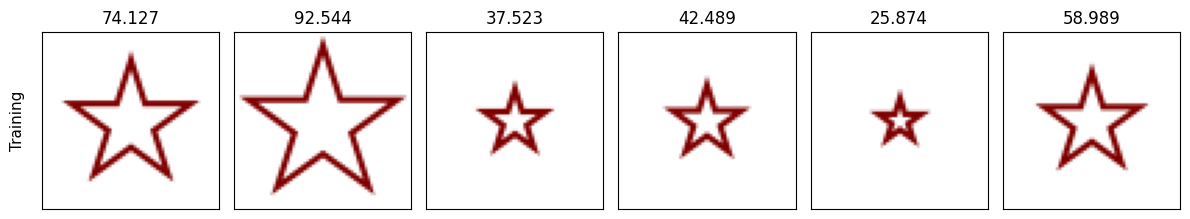

In [6]:
show_datasets(dataset_train)

In [7]:
device = os.environ["MGML_DEVICE"]
print(f"Training device: {device}")

model = BinnedGlyphRegressor(num_divisions=c.num_divisions)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=c.learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=c.scheduler_gamma)
generator = torch.Generator().manual_seed(c.seed)

data_loader_train = DataLoader(
    dataset_train,
    batch_size=c.batch_size,
    num_workers=c.data_loader_num_workers,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True,
    generator=generator,
)

Training device: cuda:2


In [8]:
from collections import deque

model.to(device)

step = 0
running_loss_train = 0.0
running_error_train = 0.0
num_batches_train = 0
steps_per_virtual_epoch = math.ceil(len(dataset_train) / c.batch_size)
validate_every_n_steps = steps_per_virtual_epoch

recent_train_losses = deque(maxlen=20)

train_iterator = iter(data_loader_train)

while step < c.max_steps:
    model.train()

    try:
        inputs, labels = next(train_iterator)
    except StopIteration:
        train_iterator = iter(data_loader_train)
        inputs, labels = next(train_iterator)

    inputs = inputs.to(device, non_blocking=True).float()
    labels = labels.to(device, non_blocking=True).float().view(-1)

    optimizer.zero_grad()
    logits: torch.Tensor = model(inputs)
    preds = model.logits_to_labels(logits)

    loss = criterion(preds, labels)
    loss.backward()
    optimizer.step()
    scheduler.step()

    error = torch.mean(torch.abs(preds - labels)).item()

    running_loss_train += loss.item()
    running_error_train += error
    num_batches_train += 1
    recent_train_losses.append(loss.item())
    step += 1

    if step % 100 == 0 or step == c.max_steps:
        avg_recent_loss = sum(recent_train_losses) / len(recent_train_losses)
        print("=" * 80)
        print(
            f"Step {step}: loss(last {len(recent_train_losses)} avg)={avg_recent_loss:.6f}, "
            f"lr={scheduler.get_last_lr()[0]:.6f}"
        )

Step 100: loss(last 20 avg)=0.199402, lr=0.000397
Step 200: loss(last 20 avg)=0.035955, lr=0.000315
Step 300: loss(last 20 avg)=0.021406, lr=0.000251
Step 400: loss(last 20 avg)=0.013089, lr=0.000199
Step 500: loss(last 20 avg)=0.009960, lr=0.000158
Step 600: loss(last 20 avg)=0.010326, lr=0.000126
Step 700: loss(last 20 avg)=0.007515, lr=0.000100
Step 800: loss(last 20 avg)=0.006692, lr=0.000079
Step 900: loss(last 20 avg)=0.005787, lr=0.000063
Step 1000: loss(last 20 avg)=0.005378, lr=0.000050
Step 1100: loss(last 20 avg)=0.005247, lr=0.000040
Step 1200: loss(last 20 avg)=0.005050, lr=0.000032
Step 1300: loss(last 20 avg)=0.004475, lr=0.000025
Step 1400: loss(last 20 avg)=0.004753, lr=0.000020
Step 1500: loss(last 20 avg)=0.005143, lr=0.000016
Step 1600: loss(last 20 avg)=0.004424, lr=0.000013
Step 1700: loss(last 20 avg)=0.004178, lr=0.000010
Step 1800: loss(last 20 avg)=0.004284, lr=0.000008
Step 1900: loss(last 20 avg)=0.004381, lr=0.000006
Step 2000: loss(last 20 avg)=0.004190, l

Inference device: cuda:2


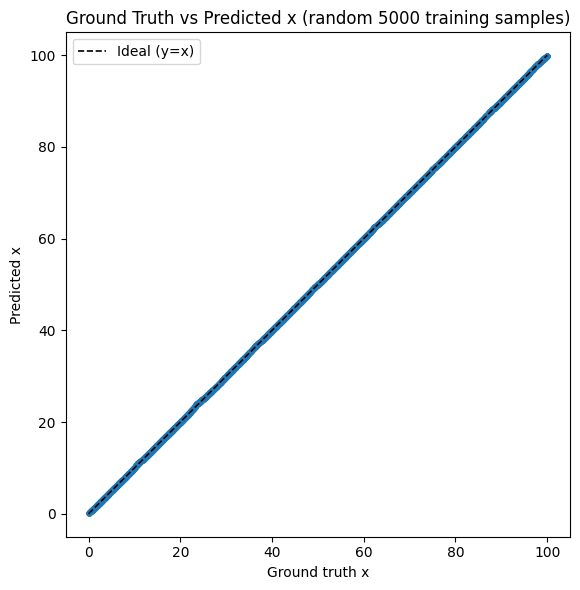

In [9]:
import random as _py_random

print(f"Inference device: {device}")

model.eval()

n_samples = min(5000, len(dataset_train))
sample_indices = _py_random.sample(range(len(dataset_train)), n_samples)

x_true = []
x_pred = []

with torch.inference_mode():
    for idx in sample_indices:
        img_tensor, label = dataset_train[idx]
        img_tensor = img_tensor.unsqueeze(0).float().to(device, non_blocking=True)
        label_value = float(label)

        logits = model(img_tensor)
        pred_value = float(model.logits_to_labels(logits).squeeze(0).item())

        x_true.append(label_value)
        x_pred.append(pred_value)

x_true = np.array(x_true)
x_pred = np.array(x_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_true, x_pred, alpha=0.5, s=12)

min_x = float(min(np.min(x_true), np.min(x_pred)))
max_x = float(max(np.max(x_true), np.max(x_pred)))
ax.plot([min_x, max_x], [min_x, max_x], linestyle="--", linewidth=1.2, color="black", label="Ideal (y=x)")

ax.set_xlabel("Ground truth x")
ax.set_ylabel("Predicted x")
ax.set_title(f"Ground Truth vs Predicted x (random {n_samples} training samples)")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

Inference device: cuda:2
Worst 5 losses: [0.11012699 0.1105388  0.11060856 0.11101873 0.11471983]
Worst 5 average loss: 0.111403


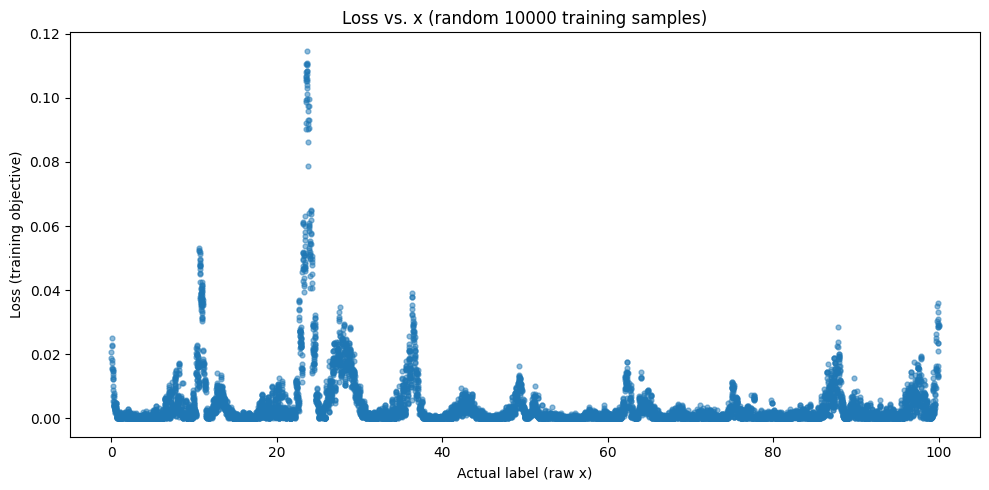

In [10]:
import random as _py_random

print(f"Inference device: {device}")

model.eval()

n_samples = min(10000, len(dataset_train))
sample_indices = _py_random.sample(range(len(dataset_train)), n_samples)

x_vals = []
losses_per_sample = []

with torch.inference_mode():
    for idx in sample_indices:
        img_tensor, label = dataset_train[idx]
        img_tensor = img_tensor.unsqueeze(0).float().to(device, non_blocking=True)
        label_value = float(label)

        logits = model(img_tensor)
        pred = model.logits_to_labels(logits).squeeze(0)

        label_tensor = torch.tensor([label_value], dtype=torch.float32, device=device)
        pred_tensor = pred.view(1)
        loss = criterion(pred_tensor, label_tensor).item()

        x_vals.append(label_value)
        losses_per_sample.append(loss)

x_vals = np.array(x_vals)
losses_per_sample = np.array(losses_per_sample)

worst_5_losses = np.sort(losses_per_sample)[-5:] if len(losses_per_sample) >= 5 else losses_per_sample
worst_5_loss_avg = float(np.mean(worst_5_losses))

if "task" in globals():
    task.logger.report_scalar(
        title="Evaluation",
        series="Worst 5 Loss Avg",
        value=worst_5_loss_avg,
        iteration=step if "step" in globals() else 0,
    )

print(f"Worst 5 losses: {worst_5_losses}")
print(f"Worst 5 average loss: {worst_5_loss_avg:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_vals, losses_per_sample, alpha=0.5, s=12)
ax.set_xlabel("Actual label (raw x)")
ax.set_ylabel("Loss (training objective)")
ax.set_title(f"Loss vs. x (random {n_samples} training samples)")
plt.tight_layout()
plt.show()

In [11]:
task.flush(wait_for_uploads=True)
task.close()

KeyboardInterrupt: 